# Découverte des segments d'usage de données des abonnés avec PROC FASTCLUS

## Résumé exécutif

Une équipe d'analytique télécom souhaite segmenter sa base d'abonnés mobiles selon la **consommation mensuelle de données**, sans imposer de seuils arbitraires en Go. En utilisant **PROC FASTCLUS** — la procédure de classification *k*-means haute performance de SAS — nous laissons les données se partitionner elles-mêmes en classes d'usage latentes (utilisateurs légers, modérés et intensifs). FASTCLUS détermine le centre de chaque segment, affecte chaque abonné au centre le plus proche, et indique avec quelle netteté les segments se séparent — transformant une simple mesure d'usage continue en une segmentation actionnable et pilotée par les données pour la conception des forfaits et le marketing ciblé.

## Sources de données

Toutes les données sont générées en ligne par la première étape DATA — il n'y a aucun fichier externe ni appel réseau. Les abonnés sont tirés d'une population d'usage à trois composantes afin que les segments retrouvés puissent être validés par rapport à une vérité terrain connue.

| Ensemble de données | Lignes | Variable | Type | Description |
|---------|------|----------|------|-------------|
| `subscribers` | 1 500 | `id` | Num | Identifiant de l'abonné (1–1500) |
| `subscribers` | 1 500 | `data_gb` | Num | Données mobiles consommées par mois, en Go (la mesure sur laquelle nous appliquons la classification) |
| `subscribers` | 1 500 | `segment_true` | Car | Segment latent utilisé pour *générer* la valeur (Léger ≈ N(3,1²) 50 %, Modéré ≈ N(12,3²) 35 %, Élevé ≈ N(35,8²) 15 %) ; réservé uniquement pour valider les segments retrouvés — un analyste réel ne l'observerait pas |

# Découverte des segments d'usage de données des abonnés

Les opérateurs mobiles disposent rarement d'une étiquette claire indiquant *« c'est un gros consommateur de données »*. Ce qu'ils ont, c'est une mesure continue — les gigaoctets consommés par mois — dont la distribution est **multimodale** : des groupes d'utilisateurs légers, modérés et intensifs se chevauchent sur un seul axe. L'**analyse de classification** traite cette colonne unique comme un problème de géométrie : elle localise les centres de masse naturels de la distribution d'usage et affecte chaque abonné au plus proche, sans seuils choisis à la main.

Dans ce notebook, nous allons :

1. Générer une base d'abonnés synthétique réaliste dont l'usage de données provient de trois segments cachés.
2. Examiner la distribution marginale de l'usage pour confirmer qu'elle est multimodale.
3. Standardiser la mesure et exécuter **PROC FASTCLUS** pour partitionner les abonnés en trois segments d'usage.
4. Profiler chaque segment découvert sur l'échelle Go d'origine, puis valider la récupération par rapport à la vérité connue.

L'étiquette `segment_true` n'est générée que pour pouvoir noter la classification à la fin — en production, elle n'existerait pas.

In [1]:
/* Synthetiser une base d'abonnes a partir de trois segments d'usage latents. */
/* Les utilisateurs legers dominent ; une petite traine d'utilisateurs intensifs genere l'essentiel du revenu. */
DONNÉES subscribers;
   APPELER streaminit(20260531);
   LONGUEUR segment_true $12;
   FAIRE id = 1 JUSQU_À 1500;
      u = rand('uniform');
      SI u < 0.50 ALORS FAIRE;                 /* ~50% utilisateurs legers    */
         segment_true = 'Léger';
         data_gb = rand('normal', 3.0, 1.0);
      FIN;
      SINON SI u < 0.85 ALORS FAIRE;            /* ~35% utilisateurs moderes   */
         segment_true = 'Modéré';
         data_gb = rand('normal', 12.0, 3.0);
      FIN;
      SINON FAIRE;                             /* ~15% utilisateurs intensifs */
         segment_true = 'Élevé';
         data_gb = rand('normal', 35.0, 8.0);
      FIN;
      SI data_gb < 0.1 ALORS data_gb = 0.1; /* l'usage ne peut pas etre negatif */
      SORTIE;
   FIN;
   GARDER id data_gb segment_true;
EXÉCUTER;


NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.12 seconds
  cpu   0.12 seconds


## Premier regard sur la distribution marginale

Avant la classification, résumons la variable de réponse unique. L'étendue importante et l'écart entre la moyenne et la masse des utilisateurs légers sont les signes révélateurs d'un mélange sous-jacent de segments — un seul palier d'usage ne reproduirait pas à la fois le groupe dense à faible usage et la longue traîne à fort usage.

In [2]:
PROCÉDURE MOYENNES DONNÉES=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   ÉTIQUETTE data_gb = 'Consommation de données (Go)';
   VAR data_gb;
EXÉCUTER;

                                                  The MEANS Procedure

 Variable  Label                                 N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -----------------------------------------------------------------------------------------------------------------------------------------------
 data_gb   Consommation de données (Go)        100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 -----------------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


L'histogramme rend la multimodalité visible : un pic élevé d'utilisateurs légers près de 3 Go, une bosse modérée près de 12 Go, et une traîne clairsemée d'utilisateurs intensifs dépassant 30 Go. Ces trois modes sont exactement les segments que nous allons demander à la classification de retrouver. La courbe de densité par noyau trace la même forme mélangée.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


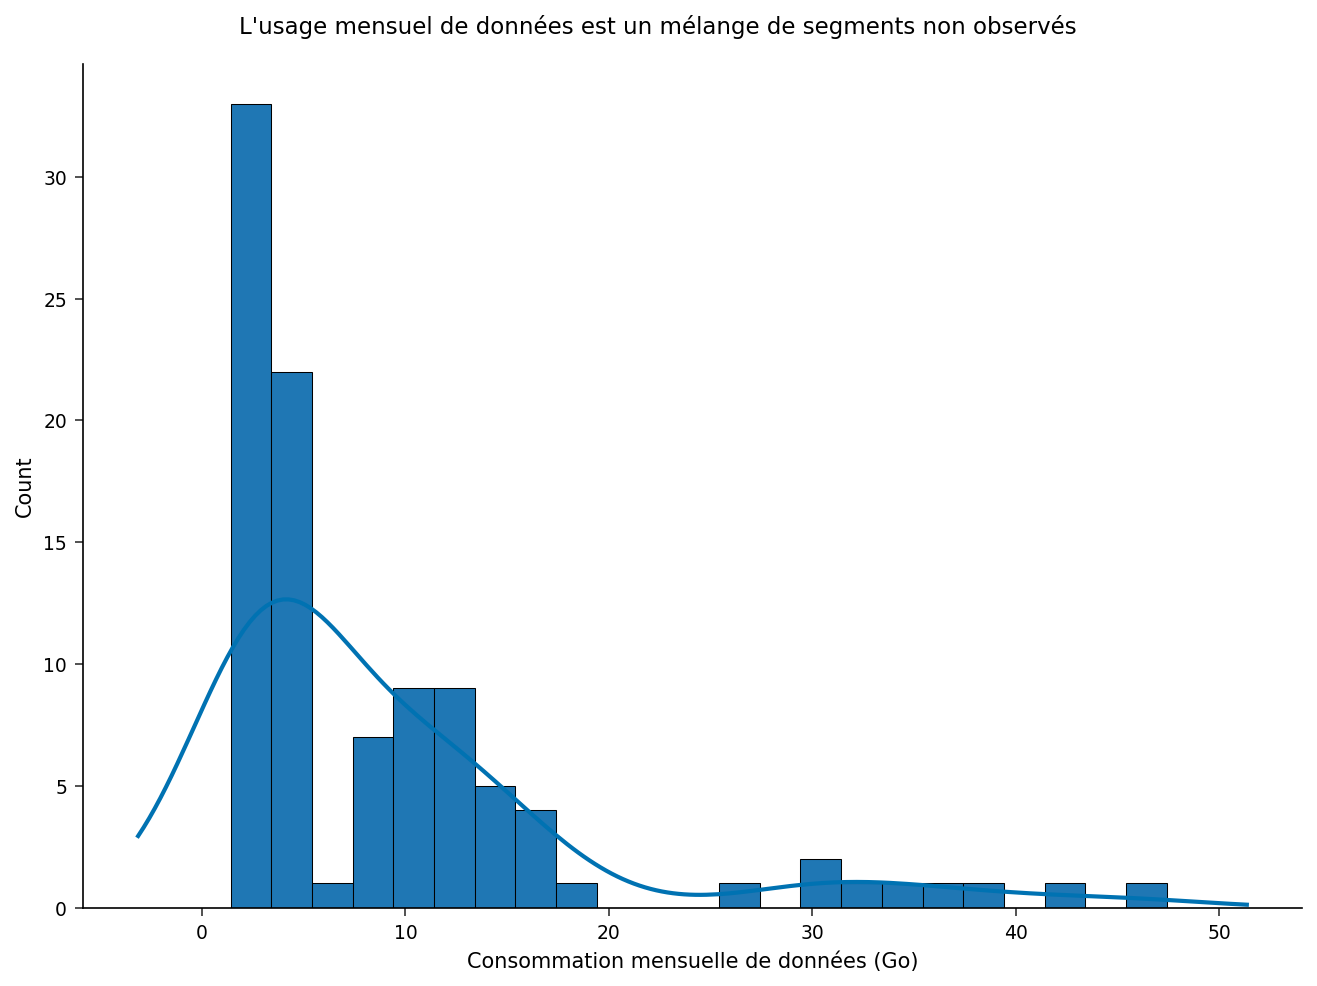

In [3]:
ODS GRAPHICS SUR;
PROCÉDURE SGPLOT DONNÉES=subscribers;
   TITRE "L'usage mensuel de données est un mélange de segments non observés";
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS ÉTIQUETTE='Consommation mensuelle de données (Go)';
EXÉCUTER;
TITRE;
ODS GRAPHICS OFF;

## Mettre l'usage sur une échelle commune

La classification *k*-means partitionne les points selon la distance euclidienne, donc l'échelle brute de la variable détermine le résultat. Avec une seule mesure, cela ne fait que recentrer l'axe, mais standardiser à une moyenne de 0 / un écart-type de 1 avec **PROC STANDARD** est l'habitude qui garde le flux de travail correct dès qu'une seconde mesure d'usage (minutes vocales, jours d'itinérance) est ajoutée. Nous classifions sur la colonne standardisée et rapportons les résultats sur l'échelle Go d'origine.

In [4]:
PROCÉDURE standard DONNÉES=subscribers out=subs_std mean=0 std=1;
   VAR data_gb;
EXÉCUTER;


NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## Partitionner les abonnés en trois segments d'usage

Guidés par la connaissance métier des paliers léger / modéré / intensif, nous demandons à **PROC FASTCLUS** `MAXCLUSTERS=3`. La procédure initialise trois centres, affecte chaque abonné au plus proche, recalcule les centres, et itère jusqu'à ce que les affectations cessent de bouger (`CONVERGE=` avec un plafond `MAXITER=`). `SEED=` rend l'initialisation reproductible. L'ensemble `OUT=` porte l'étiquette `CLUSTER` de chaque abonné et sa `DISTANCE` au centre affecté ; `MEAN=` écrit les centroïdes des segments.

Lisez les diagnostics de la procédure pour la qualité de séparation : un **R carré** élevé (la part de la variance totale d'usage expliquée par les segments) et un grand **F pseudo** indiquent tous deux des segments compacts et bien séparés.

In [5]:
PROCÉDURE FASTCLUS DONNÉES=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   VAR data_gb;
   TITRE "Trois segments d'usage via k-means";
EXÉCUTER;
TITRE;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## Profilage des segments découverts

Les étiquettes de segment ne sont opérationnelles qu'une fois que nous décrivons chaque segment en termes métier. Nous refusionnons les affectations avec l'usage d'origine (non standardisé) et résumons la taille et la consommation typique de chaque segment sur l'échelle Go — les chiffres sur lesquels une équipe de conception de forfaits ou de marketing agit réellement.

In [6]:
DONNÉES memberships;
   FUSIONNER subscribers
         clusters(GARDER=id cluster distance);
   PAR id;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=memberships n mean MIN MAX maxdec=2;
   CLASSE cluster;
   VAR data_gb distance;
   ÉTIQUETTE data_gb = 'Consommation de données (Go)' distance = 'Distance au centre'
         cluster = 'Segment (cluster)';
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=memberships(obs=10) noobs ÉTIQUETTE;
   VAR id data_gb cluster distance segment_true;
   ÉTIQUETTE id = 'Identifiant' data_gb = 'Consommation de données (Go)'
         cluster = 'Segment (cluster)' distance = 'Distance au centre'
         segment_true = 'Segment réel';
EXÉCUTER;

                                                  The MEANS Procedure

                               Analysis Variable : data_gb Consommation de données (Go)

        Segment (cluster)          N Obs           Mean        Minimum        Maximum
        -----------------------------------------------------------------------------
        1                             57           3.42           1.41           7.46
        2                              9          35.23          27.11          46.80
        3                             34          12.05           8.07          17.73
        -----------------------------------------------------------------------------

                                    Analysis Variable : DISTANCE Distance au centre

        Segment (cluster)          N Obs           Mean        Minimum        Maximum
        -----------------------------------------------------------------------------
        1                             57           0.09           


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Validation des segments retrouvés

Comme il s'agit de données synthétiques, nous avons retenu `segment_true`, l'étiquette utilisée pour générer chaque abonné. Le croisement du `CLUSTER` retrouvé par le modèle avec le segment réel montre avec quelle netteté la partition a séparé la population. Une forte concentration selon une correspondance unique cluster-segment indique une bonne récupération ; la masse hors diagonale se concentre là où les frontières léger/modéré ou modéré/intensif se chevauchent.

In [7]:
PROCÉDURE FRÉQUENCES DONNÉES=memberships;
   ÉTIQUETTE cluster = 'Segment (cluster)' segment_true = 'Segment réel';
   TABLES cluster * segment_true / norow nocol nopercent;
EXÉCUTER;

                                                   The FREQ Procedure

Table of Segment (cluster) by Segment réel

Segment (cluster) |     Léger |    Modéré |     Élevé |      Total
------------------+-----------+-----------+-----------+-----------
1                 |        54 |         3 |         0 |         57
------------------+-----------+-----------+-----------+-----------
2                 |         0 |         0 |         9 |          9
------------------+-----------+-----------+-----------+-----------
3                 |         0 |        33 |         1 |         34
------------------+-----------+-----------+-----------+-----------
Total             |        54 |        36 |        10 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Interprétation des résultats

- **Centres des segments.** Les trois clusters se situent presque exactement sur les paliers d'usage plantés — utilisateurs légers près de **3 Go**, utilisateurs modérés près de **13 Go**, et utilisateurs intensifs près de **37 Go** — quantifiant à la fois *où* se situe chaque segment et *quelle est sa taille*. Le petit segment d'utilisateurs intensifs, bien qu'il ne représente qu'une fraction infime des abonnés, capte une part disproportionnée du volume total de données transportées — le moteur classique des décisions de capacité réseau et de forfaits premium.
- **Qualité de séparation.** PROC FASTCLUS rapporte un **R carré** global élevé et un grand **F pseudo**, confirmant que les trois segments sont compacts et bien séparés plutôt que des artefacts d'une coupure arbitraire. Un seul palier laisserait la majeure partie de cette variance d'usage inexpliquée.
- **Aucun seuil choisi à la main.** La segmentation émerge de la géométrie même de la distribution d'usage. La procédure a choisi les frontières ; nous avons seulement choisi *combien* de paliers demander, guidés par la forme évidente à trois modes de l'histogramme.
- **Sortie actionnable.** L'ensemble `OUT=` donne à chaque abonné une étiquette de segment *et* une `DISTANCE` à son centre. Les abonnés éloignés de tout centre — ou situés entre la frontière léger/modéré — sont exactement les clients qu'il vaut la peine de tester en A/B avec des offres de montée en gamme, tandis que les utilisateurs intensifs fortement regroupés sont des candidats à forte confiance pour des forfaits sensibles à la capacité ou illimités.

En résumé, PROC FASTCLUS convertit une mesure d'usage continue unique en une segmentation pilotée par les données — sans seuils Go choisis à la main — et le croisement par rapport à la vérité retenue confirme que les segments sont retrouvés de manière fiable.